<div class="frontmatter text-center">
<h1>Geospatial Data Science</h1>
<h2>Lecture 10: Spatial networks</h2>
<h3>IT University of Copenhagen, Spring 2025</h3>
<h3>Instructor: Clément Sebastiao</h3>
</div>

# Source
This notebook was adapted from:

* OSMnx examples: https://github.com/gboeing/osmnx-examples/blob/main/notebooks/06-stats-indicators-centrality.ipynb
* Spaghetti: https://pysal.org/spaghetti/notebooks/network-spatial-dependence.html

In [1]:
import os
os.environ['PROJ_LIB'] = '/opt/conda/share/proj'

In [2]:
import geopandas as gpd
import osmnx as ox
import numpy as np
import networkx as nx
import pandas as pd

from haversine import haversine, haversine_vector

import matplotlib.pyplot as plt
from scipy.spatial import Delaunay, delaunay_plot_2d, Voronoi, voronoi_plot_2d

import matplotlib
import spaghetti
import matplotlib_scalebar
from matplotlib_scalebar.scalebar import ScaleBar

%matplotlib inline
ox.__version__

/opt/conda/lib/python3.9/site-packages/esda/getisord.py:636: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if __name__ is "__main__":
/opt/conda/lib/python3.9/site-packages/spaghetti/network.py:36: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(f"{dep_msg}", FutureWarning)


'1.1.2'

# Haversine distance

Always use the Haversine distance when calculating distances between far away points: https://github.com/mapado/haversine

In [3]:
copenhagen = (55.67594, 12.56553)  # (lat, lon)
london = (51.509865, -0.118092)
sanfrancisco = (37.773972, -122.431297)
newyork = (40.730610, -73.935242)

In [4]:
haversine(copenhagen, sanfrancisco)

8784.87818320771

In [5]:
haversine_vector(3*[copenhagen], [london, newyork, sanfrancisco])

array([ 954.68540063, 6182.52042412, 8784.87818321])

# Use OSMnx to calculate street network indicators

First we download the Frederiksberg drive network with OSMnx:

In [6]:
place = "Frederiksberg Municipality"
G = ox.graph_from_place(place, network_type="drive")
G_proj = ox.project_graph(G)

/opt/conda/lib/python3.9/site-packages/osmnx/geocoder.py:110: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  gdf = gdf.append(_geocode_query_to_gdf(q, wr, by_osmid))


## Calculate basic street network measures (topological and geometric)

In [7]:
# Calculate Frederiksberg's basic stats, then show the average circuity
stats = ox.basic_stats(G)
stats["circuity_avg"]

1.0268454820545145

To calculate density-based stats, you must also pass the network's bounding area in square meters (otherwise basic_stats() will just skip them in the calculation):

In [8]:
# get the street network for a place, and its area in square meters
city = ox.geocode_to_gdf(place)
city_proj = ox.project_gdf(city)
area = city_proj.unary_union.area
area

/opt/conda/lib/python3.9/site-packages/osmnx/geocoder.py:110: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  gdf = gdf.append(_geocode_query_to_gdf(q, wr, by_osmid))


8705602.051319553

In [9]:
# calculate basic and extended network stats, merge them together, and display
stats = ox.basic_stats(G, area=area)
pd.Series(stats)

n                                                                             810
m                                                                            1941
k_avg                                                                    4.792593
edge_length_total                                                      185697.813
edge_length_avg                                                         95.671207
streets_per_node_avg                                                     2.898765
streets_per_node_counts         {0: 0, 1: 109, 2: 25, 3: 521, 4: 150, 5: 4, 6: 1}
streets_per_node_proportions    {0: 0.0, 1: 0.1345679012345679, 2: 0.030864197...
intersection_count                                                            701
street_length_total                                                    109564.591
street_segment_count                                                         1153
street_length_avg                                                       95.025664
circuity_avg    

Streets/intersection counts and proportions are nested dicts inside the stats dict. To convert these stats to a pandas dataframe (to compare/analyze multiple networks against each other), just unpack these nested dicts first:

In [10]:
# unpack dicts into individiual keys:values
stats = ox.basic_stats(G, area=area)
for k, count in stats["streets_per_node_counts"].items():
    stats["{}way_int_count".format(k)] = count
for k, proportion in stats["streets_per_node_proportions"].items():
    stats["{}way_int_prop".format(k)] = proportion

# delete the no longer needed dict elements
del stats["streets_per_node_counts"]
del stats["streets_per_node_proportions"]

# load as a pandas dataframe
pd.DataFrame(pd.Series(stats, name="value")).round(3)

,value
n,810.000
m,1941.000
k_avg,4.793
edge_length_total,185697.813
edge_length_avg,95.671
streets_per_node_avg,2.899
intersection_count,701.000
street_length_total,109564.591
street_segment_count,1153.000
street_length_avg,95.026


### Inspect betweenness centrality

In [11]:
# calculate betweenness with a digraph of G (ie, no parallel edges)
bc = nx.betweenness_centrality(ox.get_digraph(G), weight="length")
max_node, max_bc = max(bc.items(), key=lambda x: x[1])
max_node, max_bc

(576734, 0.2524691282478062)

In Frederiksberg Municipality, the node with the highest betweenness centrality has 25% of all shortest paths running through it. Let's highlight it in the plot:

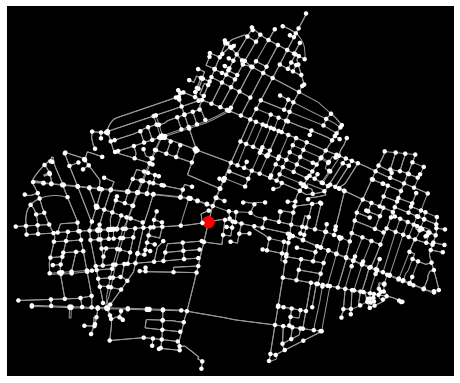

In [12]:
nc = ["r" if node == max_node else "w" for node in G.nodes]
ns = [150 if node == max_node else 20 for node in G.nodes]
fig, ax = ox.plot_graph(G, node_size=ns, node_color=nc, node_zorder=2, bgcolor="k")

~25% of all shortest paths run through the node highlighted in red. Let's look at the relative betweenness centrality of every node in the graph:

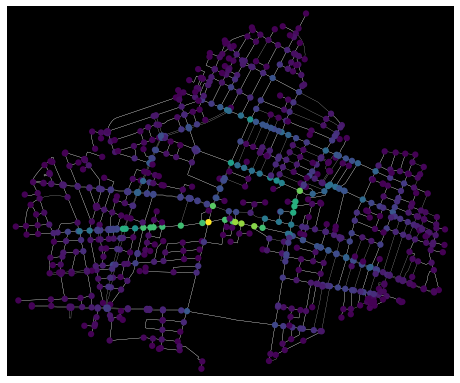

In [13]:
# add the betweenness centrality values as new node attributes, then plot
nx.set_node_attributes(G, bc, "bc")
nc = ox.plot.get_node_colors_by_attr(G, "bc", cmap="viridis")
fig, ax = ox.plot_graph(
    G,
    node_color=nc,
    node_size=40,
    node_zorder=2,
    edge_linewidth=0.2,
    edge_color="w",
    bgcolor="k",
)

Above, the nodes are visualized by betweenness centrality, from low (dark violet) to high (light yellow). The colors in the colorspace are linearly mapped to the attribute values.

# Delaunay triangulation and Voronoi diagram

Let's showcase the Delaunay traingulation and the Voronoi diagram for pharmacies in Frederiksberg. In particular, the Voronoi diagram will tell us: What is the closest pharmacy to any location in Frederiksberg?

In [14]:
# Let's fetch all pharmacies and project them
tags = {'amenity': ['pharmacy']}
gdf_pharmacies = ox.geometries_from_place(place, tags=tags)
gdf_pharmacies = ox.project_gdf(gdf_pharmacies)
gdf_pharmacies

/opt/conda/lib/python3.9/site-packages/osmnx/geocoder.py:110: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  gdf = gdf.append(_geocode_query_to_gdf(q, wr, by_osmid))


amenity                       name  \
element_type osmid                                             
node         2955867754  pharmacy    Dalgas Boulevard Apotek   
             4886221183  pharmacy           Apoteket Godthåb   
             6579860143  pharmacy         Smallegades Apotek   
             6959994877  pharmacy                   Apoteket   
             7144688116  pharmacy              Apotek Ørsted   
             8254386587  pharmacy         Apotek Borups Allé   
             8367053969  pharmacy  Frederiksberg Løve Apotek   
             9089831028  pharmacy       Frederiksberg Apotek   

                                                             opening_hours  \
element_type osmid                                                           
node         2955867754  Mo-Th 09:00-17:30; Fr 09:00-18:00; Sa 09:30-13:30   
             4886221183                  Mo-Fr 09:00-19:00; Sa 09:30-16:00   
             6579860143  08:00-17:30; Sa 09:00-13:30; Su off; Jan 1 off...   
             6959994877                                                NaN   
             7144688116                                  Mo-Su 08:00-20:00   
             8254386587                                        08:00-20:00   
             8367053969  Mo-We 09:30-18:00; Th-Fr 10:00-18:00; Sa 09:30...   
             9089831028                                                NaN   

                        toilets:wheelchair  \
element_type osmid                           
node         2955867754                 no   
             4886221183                NaN   
             6579860143                NaN   
             6959994877                NaN   
             7144688116                NaN   
             8254386587                NaN   
             8367053969                NaN   
             9089831028                NaN   

                                                                   website  \
element_type osmid                                                           
node         2955867754  https://a-apoteket.dk/593/frederiksberg-dalgas...   
             4886221183                                                NaN   
             6579860143                  https://smallegade.apotekeren.dk/   
             6959994877                                                NaN   
             7144688116                                                NaN   
             8254386587                                                NaN   
             8367053969                                                NaN   
             9089831028                    https://frederiksbergapotek.dk/   

                        wheelchair                        geometry  \
element_type osmid                                                   
node         2955867754        yes  POINT (343488.521 6173461.280)   
             4886221183        NaN  POINT (345229.807 6173831.459)   
             6579860143        yes  POINT (344297.368 6173210.557)   
             6959994877        NaN  POINT (344800.948 6173377.782)   
             7144688116        NaN  POINT (345873.157 6173198.925)   
             8254386587        NaN  POINT (344958.792 6174746.866)   
             8367053969        yes  POINT (345292.193 6173817.514)   
             9089831028        NaN  POINT (345066.585 6172979.164)   

                                              fvst:name fvst:navnelbnr  \
element_type osmid                                                       
node         2955867754                             NaN            NaN   
             4886221183  Frederiksberg Apoteket Godthåb         905864   
             6579860143                             NaN         519499   
             6959994877                             NaN            NaN   
             7144688116                             NaN         909881   
             8254386587                             NaN            NaN   
             8367053969                             NaN            Na

In [15]:
# Let's extract the coordinates
pharmacies_coords = np.vstack((
    np.array(gdf_pharmacies.geometry.x),
    np.array(gdf_pharmacies.geometry.y)
)).T
pharmacies_coords

array([[ 343488.52137855, 6173461.27954614],
       [ 345229.80663513, 6173831.45918688],
       [ 344297.36826902, 6173210.5565033 ],
       [ 344800.94761035, 6173377.78158292],
       [ 345873.15652438, 6173198.92544987],
       [ 344958.79160712, 6174746.86613936],
       [ 345292.19260676, 6173817.51436977],
       [ 345066.58541096, 6172979.16380171]])

## Delaunay triangulation

/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


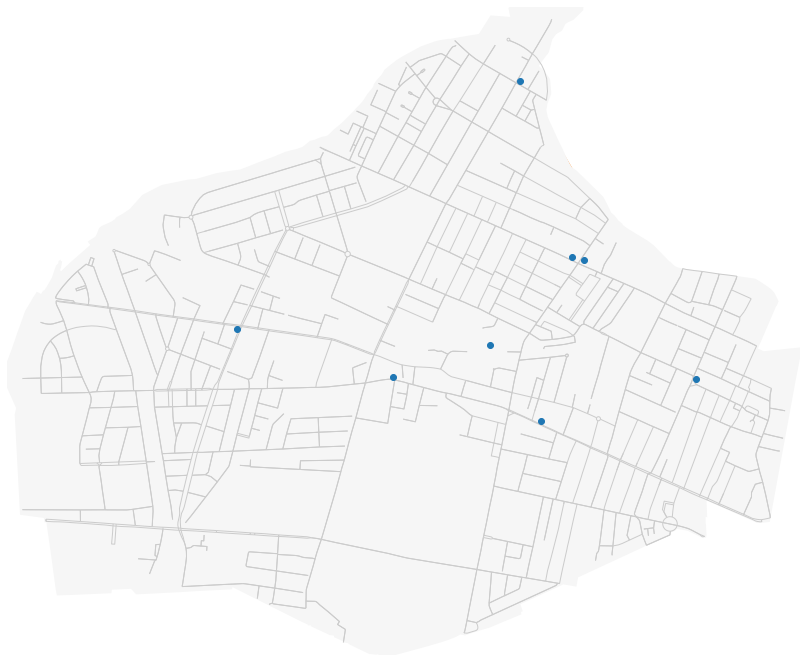

In [16]:
tri = Delaunay(pharmacies_coords)
fig = plt.figure(figsize=(12, 9))
axes = fig.add_axes([0, 0, 1, 1])
delaunay_plot_2d(tri, ax=axes);

# Plot city border
city_proj.plot(fc="#F6F6F6", ec="none", ax=axes);

# Plot street network
ox.plot_graph(G_proj, node_size=0, bgcolor="w", ax=axes, edge_color="#CCCCCC");

## Voronoi diagram

/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


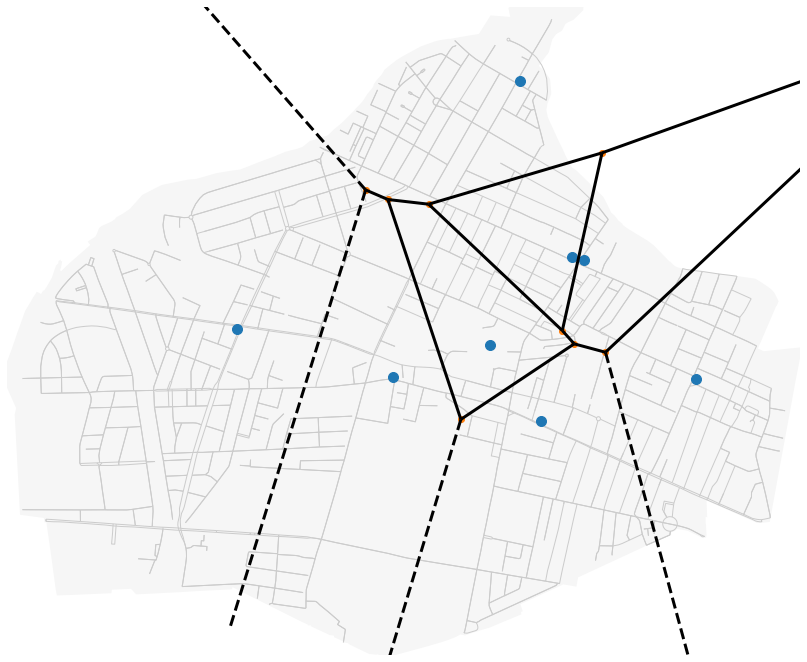

In [17]:
vor = Voronoi(pharmacies_coords)
fig = plt.figure(figsize=(12, 9))
axes = fig.add_axes([0, 0, 1, 1])
voronoi_plot_2d(vor, ax=axes, line_width = 3, point_size=20);

# Plot city border
city_proj.plot(fc="#F6F6F6", ec="none", ax=axes);

# Plot street network
ox.plot_graph(G_proj, node_size=0, bgcolor="w", ax=axes, edge_color="#CCCCCC");

Voila! The thick black lines show us the areas closest to each pharmacy (blue).

# Network-constrained spatial clustering with Ripley's K using Spaghetti

Ripley's K function takes a point pattern and considers all pairwise distances of nearest neighbors to determine the existence of clustering, or lack thereof, over a delineated range of distances: https://en.wikipedia.org/wiki/Spatial_descriptive_statistics#Ripley's_K_and_L_functions

However, using Ripley's K for urban amenities is wrong: Amenities cannot be reached as the crow flies -you can't move through buildings-, but only over the street network. The Spaghetti package is part of PySAL - it allows to constrain spatial dependence to a street network: https://pysal.org/spaghetti/notebooks/network-spatial-dependence.html It combines point pattern analysis with spatial networks. It has tools to snap points to a network and to analyze point patterns constrained to the network, which can be very useful for asking questions like "How clustered are pubs/pharmacies *on the street network*?"

We want to analyze two point of interest (POI) datasets in Frederiksberg: 1) Pubs+Restaurants, and 2) Pharmacies (from above). Let's fetch and project the new dataset, pubs+restaurants:

In [18]:
tags = {'amenity': ['pub', 'restaurant']}
gdf_pubs = ox.geometries_from_place(place, tags=tags)
gdf_pubs = ox.project_gdf(gdf_pubs)
gdf_pubs

/opt/conda/lib/python3.9/site-packages/osmnx/geocoder.py:110: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  gdf = gdf.append(_geocode_query_to_gdf(q, wr, by_osmid))


amenity fvst:navnelbnr  \
element_type osmid                                   
node         277694702          pub         115321   
             277703258          pub         111210   
             278380921          pub         921122   
             278389273          pub         738934   
             279143638   restaurant         115050   
...                             ...            ...   
             9103890446  restaurant         992059   
             9156241499  restaurant         980186   
             9217106974  restaurant        1111573   
             9280775697  restaurant        1144806   
             9415784788  restaurant        1204350   

                                               name  \
element_type osmid                                    
node         277694702                  Cafe Intime   
             277703258                   Alléenberg   
             278380921                   Cafe Svejk   
             278389273                   Promenaden   
             279143638                 Viet Nam Nam   
...                                             ...   
             9103890446  Shirzad Persisk Restaurant   
             9156241499             Koreansk B.B.Q.   
             9217106974              Bjørnekælderen   
             9280775697                     Circolo   
             9415784788                      Taigoo   

                                                             opening_hours  \
element_type osmid                                                           
node         277694702                                 Mo-Su 16:00 - 02:00   
             277703258                                   Tu-Sa 22:00-05:00   
             278380921                 Su-Mo 12:00-24:00;Tu-Sa 12:00-02:00   
             278389273                                                 NaN   
             279143638                                         16:00-23:00   
...                                                                    ...   
             9103890446                                                NaN   
             9156241499                                                NaN   
             9217106974                             11:30-23:00; Su-Tu off   
             9280775697  17:30-24:00;Sa 11:30-15:30,17:30-24:00;Su 11:3...   
             9415784788                14:00-22:00; Sa 14:00-19:00; Su off   

                                   phone ref:DK:cvr ref:DK:cvr:pnummer  \
element_type osmid                                                       
node         277694702   +45 38 34 19 58   27979440         1010696328   
             277703258      +45 33254442   25689097         1007991440   
             278380921      +45 38862560   40692932         1024914271   
             278389273               NaN   39126680         1023555944   
             279143638               NaN   54395957         1014630240   
...                                  ...        ...                ...   
             9103890446     +45 35858688   26916186         1027158397   
             9156241499     +45 60663669   42000558         1026654641   
             9217106974     +45 47477747   42518824         1027322286   
             9280775697     +45 51302120   42228567         1026929578   
             9415784788     +45 12345678   42670499         1027527643   

                        toilets                            website   wikidata  \
element_type osmid                                                              
node         277694702      yes          http://www.cafeintime.dk/  Q12305023   
             277703258      yes          http://www.alleenberg.dk/        NaN   
             278380921      NaN                                NaN        NaN   
             278389273      NaN                                NaN        NaN   
             279143638      NaN         http://www.viet-namnam.dk/        NaN   
...                         ...                                .

/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are depreca

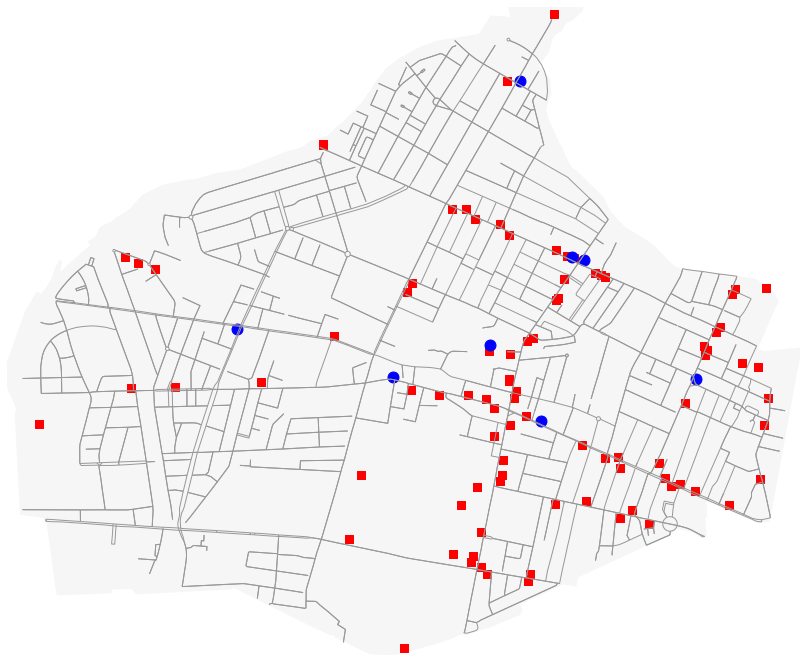

In [19]:
fig = plt.figure(figsize=(12, 9))
axes = fig.add_axes([0, 0, 1, 1])

# Plot city border
city_proj.plot(fc="#F6F6F6", ec="none", ax=axes);

# Plot the two POI datasets
gdf_pubs.plot(ax=axes, color="r", markersize=60, marker="s")
gdf_pharmacies.plot(ax=axes, color="b", markersize=120)

# Plot street network
ox.plot_graph(G_proj, node_size=0, bgcolor="w", ax=axes);

We first need a helper function for nice plotting (adapted from https://pysal.org/spaghetti/notebooks/network-spatial-dependence.html#Results-plotting-helper-function)

In [20]:
def plot_k(k, _arcs, df1, df2, obs, scale=True, wr=[1, 1.2], size=(14, 7)):
    """Plot a Global Auto K-function and spatial context."""
    def function_plot(f, ax):
        """Plot a Global Auto K-function."""
        ax.plot(k.xaxis, k.observed, "b-", linewidth=1.5, label="Observed")
        ax.plot(k.xaxis, k.upperenvelope, "r--", label="Upper")
        ax.plot(k.xaxis, k.lowerenvelope, "k--", label="Lower")
        ax.legend(loc="best", fontsize="x-large")
        title_text = "Global Auto $K$ Function: %s\n" % obs
        title_text += "%s steps, %s permutations," % (k.nsteps, k.permutations)
        title_text += " %s distribution" % k.distribution
        f.suptitle(title_text, fontsize=25, y=1.1)
        ax.set_xlabel("Distance $(r)$", fontsize="x-large")
        ax.set_ylabel("$K(r)$", fontsize="x-large")

    def spatial_plot(ax):
        """Plot spatial context."""
        base = _arcs.plot(ax=ax, color="k", alpha=0.25)
        df1.plot(ax=base, color="g", markersize=30, alpha=0.25)
        df2.plot(ax=base, color="g", marker="x", markersize=100, alpha=0.5)
        carto_elements(base, scale)

    sub_args = {"gridspec_kw":{"width_ratios": wr}, "figsize":size}
    fig, arr = matplotlib.pyplot.subplots(1, 2, **sub_args)
    function_plot(fig, arr[0])
    spatial_plot(arr[1])
    fig.tight_layout()

def carto_elements(b, scale):
    """Add/adjust cartographic elements."""
    if scale:
        kw = {"units":"m", "dimension":"si-length", "fixed_value":1000}
        b.add_artist(ScaleBar(1, **kw))
    b.set(xticklabels=[], xticks=[], yticklabels=[], yticks=[]);

Because spaghetti has no OSMnx integration, we need to use shapefiles for example. We therefore export the graph, so that we can import it later as a spaghetti.Network

In [21]:
ox.io.save_graph_shapefile(G_proj, "Frederiksberg")

/opt/conda/lib/python3.9/site-packages/osmnx/io.py:108: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_nodes.to_file(filepath_nodes, driver="ESRI Shapefile", index=True, encoding=encoding)
/opt/conda/lib/python3.9/site-packages/geopandas/io/file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:
/opt/conda/lib/python3.9/site-packages/geopandas/io/file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


Now we build the spaghetti.Network from the shape file:

In [22]:
ntw = spaghetti.Network(in_data="Frederiksberg/edges.shp")
vertices_df, arcs_df = spaghetti.element_as_gdf(
    ntw, vertices=ntw.vertex_coords, arcs=ntw.arcs
)

/opt/conda/lib/python3.9/site-packages/spaghetti/network.py:308: ResourceWarning: unclosed file <_io.BufferedReader name='Frederiksberg/edges.shp'>
  self._extractnetwork()
/opt/conda/lib/python3.9/site-packages/spaghetti/network.py:308: ResourceWarning: unclosed file <_io.BufferedReader name='Frederiksberg/edges.shx'>
  self._extractnetwork()


Snapping pubs and pharmacies to our street network, creating two pointpatterns on the network:

In [23]:
ntw.snapobservations(gdf_pubs, "pubs", attribute=True)
ntw.snapobservations(gdf_pharmacies, "pharmacies", attribute=True)
ntw.pointpatterns

{'pubs': <spaghetti.network.PointPattern at 0x7f53a251a910>,
 'pharmacies': <spaghetti.network.PointPattern at 0x7f53a3b34c40>}

Saving the pointpatterns and their snapped versions as gdf, for plotting later:

In [24]:
pubs = spaghetti.element_as_gdf(ntw, pp_name="pubs")
pubs_snapped = spaghetti.element_as_gdf(ntw, pp_name="pubs", snapped=True)
pharmacies = spaghetti.element_as_gdf(ntw, pp_name="pharmacies")
pharmacies_snapped = spaghetti.element_as_gdf(ntw, pp_name="pharmacies", snapped=True)

## Clustering of pubs and restaurants

Running Ripley's K for pubs *on the network* (this can take around 2 minutes):

/opt/conda/lib/python3.9/site-packages/spaghetti/util.py:247: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  pred = numpy.array(pred, dtype=numpy.int)
/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version in

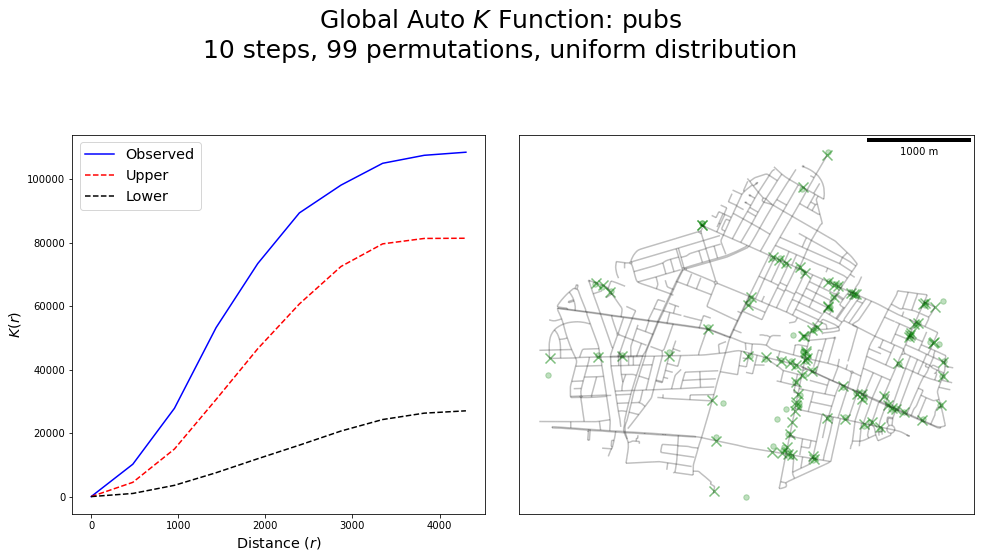

In [26]:
np.random.seed(0)
kres = ntw.GlobalAutoK(
    ntw.pointpatterns["pubs"],
    nsteps=10,
    permutations=99) # Keep permutations low here, otherwise too much time needed for computation
plot_k(kres, arcs_df, pubs, pubs_snapped, "pubs")

### Interpretation

Because the observed curve is always above the simulation envelope, pubs+restaurants are clustered on the street network **on all scales**! 

It looks like a showcase for economies of agglomeration or business cluster effects, especially Gammel Kongevej and Pile Alle/Falkoner Alle:  
https://en.wikipedia.org/wiki/Economies_of_agglomeration https://en.wikipedia.org/wiki/Business_cluster#Cluster_effect

## Clustering of pharmacies

Now let's run Ripley's K on the pharmacies. This is much faster due to the low number of points, so we can crank up the parameters:

/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
/opt/conda/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
/opt/conda/lib/python3.9/site-packages/geopandas/plotting.py:74: DeprecationWarning: distutils Version classes are depreca

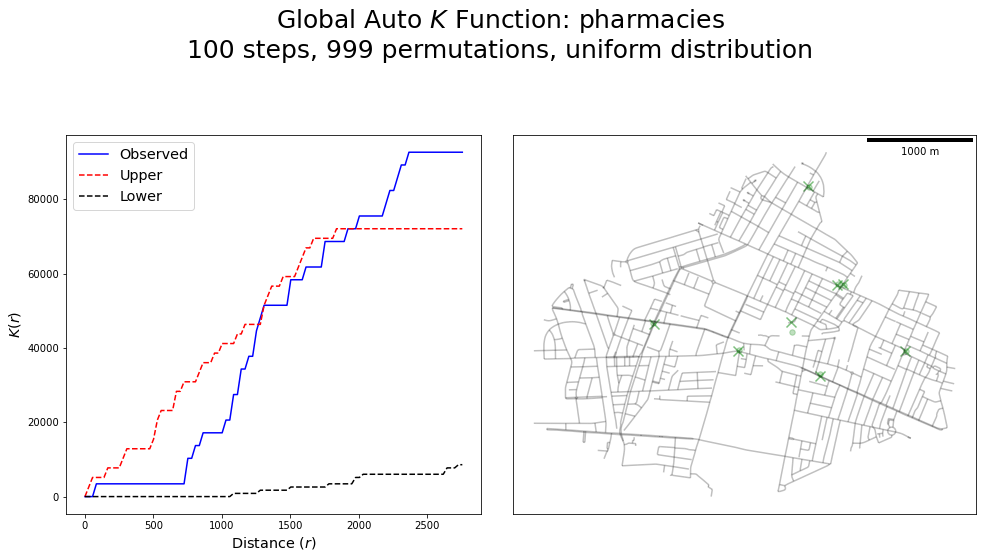

In [27]:
np.random.seed(0)
kres = ntw.GlobalAutoK(
    ntw.pointpatterns["pharmacies"],
    nsteps=100,
    permutations=999)
plot_k(kres, arcs_df, pharmacies, pharmacies_snapped, "pharmacies")

### Interpretation

Pharmacies show different clustering behavior than pubs+restaurants. If it wasn't for those two pharmacies in the north east right next to each other, their observed curve would be on the lowest end of the simulation envelope for low distances, showing that they are quite dispersed on short ranges. Maybe there are minimum distance laws in place to make pharmacies cover the city well? On the other hand, for distances above 2km, the observed curve is above the envelope, meaning clustering. On this scale, pharmacies are clustered in the east, and there is quite some empty space in the north west and south west of Frederiksberg.